This cell can ensure that the current working directory is set to the project root, so that all relative paths (e.g., results/, data/)

resolve correctly regardless of how the notebook is launched.

In [1]:



from pathlib import Path
import os

current = Path.cwd()
print("Current:", current)
PROJECT_ROOT = current.parent.parent

os.chdir(PROJECT_ROOT)

print("Now at root:", Path.cwd())

Current: D:\0-about me\2-FDU\4-CSCI 6806 CAPSTONE\1_from github\2026-winter-capstone-project-2026winter-capstone-group-11\notebooks\modeling
Now at root: D:\0-about me\2-FDU\4-CSCI 6806 CAPSTONE\1_from github\2026-winter-capstone-project-2026winter-capstone-group-11


This cell can import all required libraries for late fusion evaluation,

including NumPy for numerical operations and scikit-learn for F1-score computation.




In [2]:
import json
import numpy as np
import pandas as pd

from sklearn.metrics import f1_score, classification_report

This cell can define file paths for precomputed test logits, labels, and sequence IDs
from Model 2 (FFT-MLP, IMU+THM) and Model 3 (CNN-BiLSTM, TOF).

All paths are fixed to the canonical global test set (N = 1518) to ensure consistent late fusion evaluation.

In [3]:
#from pathlib import Path

PRED_DIR = Path("results/preds")
assert PRED_DIR.exists(), f" PRED_DIR no existing：{PRED_DIR.resolve()}"

# the path for test logits from model2 and model3;
LOGITS2_model2_PATH = PRED_DIR / "fft_mlp_imu_thm_only_test_logits.npy"   # Model2
LOGITS3_model3_PATH = PRED_DIR / "cnn_bilstm_tof_only_test_logits.npy"    # Model3


Y_TEST_PATH     = PRED_DIR / "cnn_bilstm_tof_only_canonical_test_y.npy"
SEQID_TEST_PATH = PRED_DIR / "canonical_test_seq_ids.npy"

def pick_first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


if not Y_TEST_PATH.exists():
    Y_TEST_PATH = pick_first_existing([
        PRED_DIR / "fft_mlp_imu_thm_only_test_y.npy",
        PRED_DIR / "cnn_bilstm_tof_only_test_y.npy",
        PRED_DIR / "cnn_bilstm_tof_only_canonical_test_y.npy",
        PRED_DIR / "cnn_bilstm_tof_only_canonical_test_y.npy",
    ])

if not SEQID_TEST_PATH.exists():
    SEQID_TEST_PATH = pick_first_existing([
        PRED_DIR / "fft_mlp_imu_thm_only_test_seq_ids.npy",
        PRED_DIR / "cnn_bilstm_tof_only_test_seq_ids.npy",
        PRED_DIR / "canonical_test_seq_ids.npy",
        PRED_DIR / "cnn_bilstm_tof_only_canonical_test_seq_ids.npy",
    ])

print("PRED_DIR       =", PRED_DIR.resolve())
print("LOGITS2_PATH   =", LOGITS2_model2_PATH.name, "exists?", LOGITS2_model2_PATH.exists())
print("LOGITS3_PATH   =", LOGITS3_model3_PATH.name, "exists?", LOGITS3_model3_PATH.exists())
print("Y_TEST_PATH    =", (Y_TEST_PATH.name if Y_TEST_PATH else None), "exists?", (Y_TEST_PATH.exists() if Y_TEST_PATH else False))
print("SEQID_TEST_PATH=", (SEQID_TEST_PATH.name if SEQID_TEST_PATH else None), "exists?", (SEQID_TEST_PATH.exists() if SEQID_TEST_PATH else False))

if not LOGITS2_model2_PATH.exists():
    raise FileNotFoundError(f" can not find Model2 logits：{LOGITS2_model2_PATH.resolve()}")
if not LOGITS3_model3_PATH.exists():
    raise FileNotFoundError(f" can not find Model3 logits：{LOGITS3_model3_PATH.resolve()}")
if Y_TEST_PATH is None or not Y_TEST_PATH.exists():
    raise FileNotFoundError(" can not find y_test")
if SEQID_TEST_PATH is None or not SEQID_TEST_PATH.exists():
    raise FileNotFoundError(" can not find seq_id")

PRED_DIR       = D:\0-about me\2-FDU\4-CSCI 6806 CAPSTONE\1_from github\2026-winter-capstone-project-2026winter-capstone-group-11\results\preds
LOGITS2_PATH   = fft_mlp_imu_thm_only_test_logits.npy exists? True
LOGITS3_PATH   = cnn_bilstm_tof_only_test_logits.npy exists? True
Y_TEST_PATH    = fft_mlp_imu_thm_only_test_y.npy exists? True
SEQID_TEST_PATH= fft_mlp_imu_thm_only_test_seq_ids.npy exists? True


This cell can load test logits, ground-truth labels, and sequence IDs,

and perform strict consistency checks:

Same number of samples (N); Same class dimensionality (C = 18); Matching sample order across all inputs

These assertions guarantee that late fusion is valid.

In [4]:
def load_npy(path: Path, allow_pickle=False):
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}  (resolved: {path.resolve()})")
    return np.load(path, allow_pickle=allow_pickle)

logits_model2 = load_npy(LOGITS2_model2_PATH)
logits_model3 = load_npy(LOGITS3_model3_PATH)
y_test  = load_npy(Y_TEST_PATH)
seq_id  = load_npy(SEQID_TEST_PATH, allow_pickle=True)

print("logits2:", logits_model2.shape, logits_model2.dtype)
print("logits3:", logits_model3.shape, logits_model3.dtype)
print("y_test :", y_test.shape, y_test.dtype, "unique~", len(np.unique(y_test)))
print("seq_id :", seq_id.shape, seq_id.dtype)

assert logits_model2.shape == logits_model3.shape, "Model2/Model3 logits shape to be inconsistent "
assert logits_model2.shape[0] == y_test.shape[0] == seq_id.shape[0], "N to be inconsistent"
assert logits_model2.ndim == 2, "logits should be 2D (N, C)"
num_classes = logits_model2.shape[1]
print("num_classes =", num_classes)



logits2: (1518, 18) float32
logits3: (1518, 18) float32
y_test : (1518,) int64 unique~ 18
seq_id : (1518,) object
num_classes = 18


This cell can perform logits-level late fusion as described in the paper.

The raw (pre-softmax) logits from Model 2 and Model 3 are combined using a weighted sum (0.3 / 0.7).

A numerically stable softmax is then applied to obtain final class probabilities and 18-class predictions.

In [5]:
#import numpy as np

def softmax_stable(x: np.ndarray, axis: int = 1) -> np.ndarray:
    x = x - x.max(axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=axis, keepdims=True)

# We can use the weights 0.3/0.7 from the paper directly;
model2_W2, model3_W3 = 0.3, 0.7
final_logits = model2_W2 * logits_model2 + model3_W3 * logits_model3
final_probs  = softmax_stable(final_logits, axis=1)

y_pred_18 = final_probs.argmax(axis=1)

print("final_logits:", final_logits.shape, final_logits.dtype)
print("final_probs :", final_probs.shape, final_probs.dtype)
print("y_pred_18   :", y_pred_18.shape, y_pred_18.dtype)

final_logits: (1518, 18) float32
final_probs : (1518, 18) float32
y_pred_18   : (1518,) int64


This cell can automatically derive the set of BFRB classes from the label definitions (id2label.json).

BFRB classes are defined as upper-body gestures involving pulling hair, scratching, or pinching skin,
while explicitly excluding lower-body (knee/leg) actions to match the paper's definition.

In [6]:

#import json
#from pathlib import Path

PRED_DIR = Path("results") / "preds"
ID_to_LABEL_PATH = PRED_DIR / "id2label.json"

with open(ID_to_LABEL_PATH, "r", encoding="utf-8") as f:
    id_to_label_raw = json.load(f)

id_to_label = {int(k): v for k, v in id_to_label_raw.items()}


BFRB_KEYWORDS = ["pull hair", "scratch", "pinch skin"]


EXCLUDE_KEYWORDS = ["knee", "leg"]

BFRB_CLASS_IDS = sorted([
    i for i, name in id_to_label.items()
    if any(k in name.lower() for k in BFRB_KEYWORDS)
    and not any(ex in name.lower() for ex in EXCLUDE_KEYWORDS)
])

print("BFRB_CLASS_IDS =", BFRB_CLASS_IDS)
print("BFRB labels:")
for i in BFRB_CLASS_IDS:
    print(i, "->", id_to_label[i])

assert BFRB_CLASS_IDS == [0, 1, 3, 4, 6, 7, 9, 10], (
    " BFRB_CLASS_IDS are inconsitent with the paper"
)

BFRB_CLASS_IDS = [0, 1, 3, 4, 6, 7, 9, 10]
BFRB labels:
0 -> Above ear - pull hair
1 -> Cheek - pinch skin
3 -> Eyebrow - pull hair
4 -> Eyelash - pull hair
6 -> Forehead - pull hairline
7 -> Forehead - scratch
9 -> Neck - pinch skin
10 -> Neck - scratch


This cell can compute Binary F1-score for the late fusion model.

A prediction is classified as BFRB if the summed probability over the 8 BFRB classes is >= 0.5,
following the evaluation protocol described in the paper.

In [7]:
#from sklearn.metrics import f1_score
#import numpy as np

BFRB_CLASS_IDS = np.array(BFRB_CLASS_IDS, dtype=int)

# true binary lable;
y_true_bin = np.isin(y_test, BFRB_CLASS_IDS).astype(int)

# sum the probility of 8 BFRB classes;
p_bfrb = final_probs[:, BFRB_CLASS_IDS].sum(axis=1)

# the threshold of the paper is 0.5;
y_pred_bin = (p_bfrb >= 0.5).astype(int)

binary_f1 = f1_score(y_true_bin, y_pred_bin)
print("Binary F1 =", binary_f1)

Binary F1 = 0.9710743801652892


This cell can compute Macro F1-score under the 9-class evaluation scheme: 8 individual BFRB classes and 1 aggregated non-target class

This metric evaluates fine-grained BFRB discrimination performance and is more sensitive to per-class errors than the binary setting.

In [8]:
#from sklearn.metrics import f1_score, classification_report
#import numpy as np

# map 18 classes into 9 classes;
bfrb_to_idx = {cid: i for i, cid in enumerate(BFRB_CLASS_IDS.tolist())}
map18classes_to_9classes = np.full(18, 8, dtype=int)

for cid, idx in bfrb_to_idx.items():
    map18classes_to_9classes[cid] = idx

y_true_9classes = map18classes_to_9classes[y_test]
y_pred_9classes = map18classes_to_9classes[y_pred_18]

macro_f1_9 = f1_score(y_true_9classes, y_pred_9classes, average="macro")
print("Macro F1 (9-class) =", macro_f1_9)

print("\n--- 9-class classification report ---")
print(classification_report(y_true_9classes, y_pred_9classes, digits=4))

Macro F1 (9-class) = 0.5905402175820958

--- 9-class classification report ---
              precision    recall  f1-score   support

           0     0.7107    0.7288    0.7197       118
           1     0.5000    0.4790    0.4893       119
           2     0.3390    0.3390    0.3390       118
           3     0.5385    0.4118    0.4667       119
           4     0.6124    0.6639    0.6371       119
           5     0.6723    0.6723    0.6723       119
           6     0.4309    0.6750    0.5260       120
           7     0.5714    0.4667    0.5138       120
           8     0.9741    0.9293    0.9512       566

    accuracy                         0.6943      1518
   macro avg     0.5944    0.5962    0.5905      1518
weighted avg     0.7061    0.6943    0.6967      1518



This cell can export the final outputs of Model 4 (Late Fusion Ensemble).

late_fusion_test_logits.npy;

late_fusion_test_pred18.npy;

In [9]:
#import json
#import numpy as np
#from pathlib import Path

PRED_DIR = Path("results") / "preds"
#METRIC_DIR = Path("results") / "metrics"

PRED_DIR.mkdir(parents=True, exist_ok=True)
#METRIC_DIR.mkdir(parents=True, exist_ok=True)


# after late fusion, we can get the test_logits;
np.save(
    PRED_DIR / "late_fusion_test_logits.npy",
    final_logits.astype(np.float32)
)


# after late fusion, we can get the test_pred18;
np.save(
    PRED_DIR / "late_fusion_test_pred18.npy",
    y_pred_18.astype(np.int64)
)





#with open(METRIC_DIR / "late_fusion_metrics.json", "w", encoding="utf-8") as f:
    #json.dump(metrics_model4, f, indent=2)

print("Model 4 (Late Fusion) artifacts exported:")
print(" - results/preds/late_fusion_test_logits.npy")
print(" - results/preds/late_fusion_test_pred18.npy")
#print(" - results/metrics/late_fusion_metrics.json")

Model 4 (Late Fusion) artifacts exported:
 - results/preds/late_fusion_test_logits.npy
 - results/preds/late_fusion_test_pred18.npy


This cell for plotting Model2/Model3/Model4 (late fusion) Binary F1 on a single graph:

Since we already have *_test_logits.npy for Model2/Model3 (and y_test for canonical), we can use the same approach as in the paper:

For each model: softmax(logits) yields the probabilities for 18 classes

p(BFRB) = the sum of probabilities across the 8 BFRB classes

pred_bin = (p(BFRB) >= 0.5)

Calculate the Binary F1 score with the true y_true_bin (based on whether y_test belongs to BFRB_CLASS_IDS)

Then plot Model2/Model3/Model4 (late fusion) on a single graph.

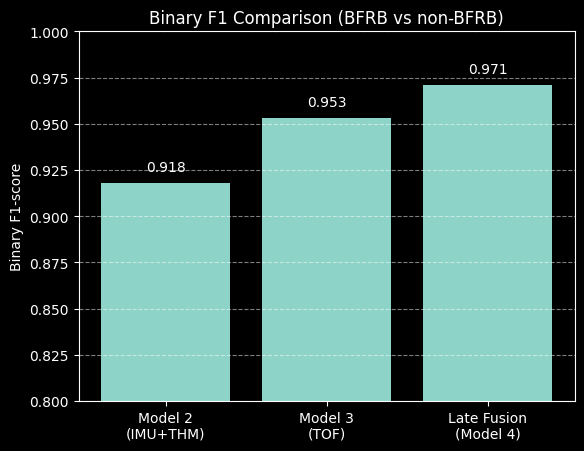

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score


PRED_DIR = Path("results") / "preds"

LOGITS2_model2_PATH = PRED_DIR / "fft_mlp_imu_thm_only_test_logits.npy"
LOGITS3_model3_PATH = PRED_DIR / "cnn_bilstm_tof_only_test_logits.npy"


Y_TEST_PATH = PRED_DIR / "cnn_bilstm_tof_only_test_y.npy"

#this line for BFRB classes (paper-consistent)
BFRB_CLASS_IDS = np.array([0, 1, 3, 4, 6, 7, 9, 10], dtype=int)

#this line for helpers
def softmax_stable(x: np.ndarray) -> np.ndarray:
    x = x - x.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)

def binary_f1_from_logits(logits: np.ndarray, y_test: np.ndarray, bfrb_ids: np.ndarray) -> float:
    probs = softmax_stable(logits)
    p_bfrb = probs[:, bfrb_ids].sum(axis=1)
    y_pred_bin = (p_bfrb >= 0.5).astype(int)               # paper threshold
    y_true_bin = np.isin(y_test, bfrb_ids).astype(int)
    return float(f1_score(y_true_bin, y_pred_bin))

#this line for load
logits_model2 = np.load(LOGITS2_model2_PATH)
logits_model3 = np.load(LOGITS3_model3_PATH)
y_test  = np.load(Y_TEST_PATH)

assert logits_model2.shape[0] == logits_model3.shape[0] == y_test.shape[0], "N mismatch"
assert logits_model2.shape[1] == logits_model3.shape[1] == 18, "Class count mismatch"

#this line for Model4: late fusion logits
w2, w3 = 0.3, 0.7
logits4 = w2 * logits_model2 + w3 * logits_model3

#this line for compute Binary F1
b2 = binary_f1_from_logits(logits_model2, y_test, BFRB_CLASS_IDS)
b3 = binary_f1_from_logits(logits_model3, y_test, BFRB_CLASS_IDS)
b4 = binary_f1_from_logits(logits4, y_test, BFRB_CLASS_IDS)

print("Binary F1 - Model2 (IMU+THM):", b2)
print("Binary F1 - Model3 (TOF):    ", b3)
print("Binary F1 - Model4 (Fusion): ", b4)

#this line for plot
models = ["Model 2\n(IMU+THM)", "Model 3\n(TOF)", "Late Fusion\n(Model 4)"]
scores = [b2, b3, b4]

plt.figure()
plt.bar(models, scores)
plt.ylim(0.8, 1.0)
plt.ylabel("Binary F1-score")
plt.title("Binary F1 Comparison (BFRB vs non-BFRB)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(scores):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom")
save_dir = Path("plots/model4")
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "model4_binary_f1.png", bbox_inches="tight")

plt.show()

This cell for plotting Model2/Model3/Model4 (late fusion) Macro F1 on a single graph:

Using the same y_test and the same 9-class mapping (8 BFRBs + 1 non-target),

calculate the Macro F1 (9-class) for Model2 / Model3 / Model4 respectively,

and then plot Model2/Model3/Model4 (late fusion) on a single graph.

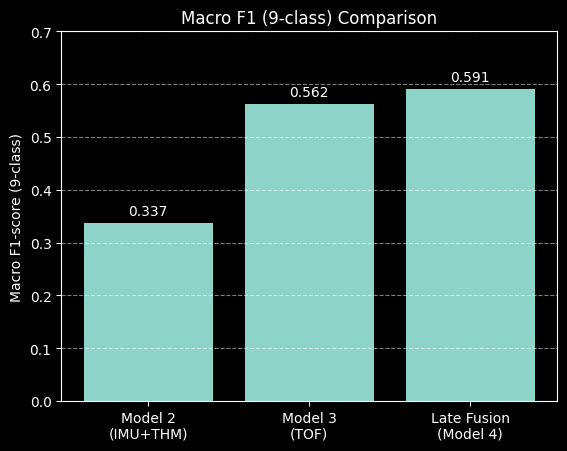

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score


PRED_DIR = Path("results") / "preds"

LOGITS2_model2_PATH = PRED_DIR / "fft_mlp_imu_thm_only_test_logits.npy"
LOGITS3_model3_PATH = PRED_DIR / "cnn_bilstm_tof_only_test_logits.npy"


Y_TEST_PATH = PRED_DIR / "cnn_bilstm_tof_only_test_y.npy"

#this line for BFRB classes (paper-consistent)
BFRB_CLASS_IDS = np.array([0, 1, 3, 4, 6, 7, 9, 10], dtype=int)

#this line for helpers
def softmax_stable(x: np.ndarray) -> np.ndarray:
    x = x - x.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)

def macro9_from_logits(logits: np.ndarray, y_test: np.ndarray, bfrb_ids: np.ndarray) -> float:
    # 18->9 mapping: 0..7 for BFRB subclasses, 8 for non-target
    map18_to_9 = np.full(18, 8, dtype=int)
    for i, cid in enumerate(bfrb_ids.tolist()):
        map18_to_9[cid] = i

    y_true_9 = map18_to_9[y_test]

    probs = softmax_stable(logits)
    y_pred_18 = probs.argmax(axis=1)
    y_pred_9 = map18_to_9[y_pred_18]

    return float(f1_score(y_true_9, y_pred_9, average="macro"))

#this line for load
logits_model2 = np.load(LOGITS2_model2_PATH)
logits_model3 = np.load(LOGITS3_model3_PATH)
y_test  = np.load(Y_TEST_PATH)

assert logits_model2.shape[0] == logits_model3.shape[0] == y_test.shape[0], "N mismatch"
assert logits_model2.shape[1] == logits_model3.shape[1] == 18, "Class count mismatch"

#this line for Model4: late fusion logits
w2, w3 = 0.3, 0.7
logits4 = w2 * logits_model2 + w3 * logits_model3

#this line for compute Macro F1 (9-class)
m2 = macro9_from_logits(logits_model2, y_test, BFRB_CLASS_IDS)
m3 = macro9_from_logits(logits_model3, y_test, BFRB_CLASS_IDS)
m4 = macro9_from_logits(logits4, y_test, BFRB_CLASS_IDS)

print("Macro F1 (9-class) - Model2 (IMU+THM):", m2)
print("Macro F1 (9-class) - Model3 (TOF):    ", m3)
print("Macro F1 (9-class) - Model4 (Fusion): ", m4)

#this line for plot
models = ["Model 2\n(IMU+THM)", "Model 3\n(TOF)", "Late Fusion\n(Model 4)"]
scores = [m2, m3, m4]

plt.figure()
plt.bar(models, scores)
plt.ylim(0.0, 0.7)
plt.ylabel("Macro F1-score (9-class)")
plt.title("Macro F1 (9-class) Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom")
save_dir = Path("plots/model4")
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "model4_macro_f1.png", bbox_inches="tight")

plt.show()

This cell can export the final output file "model4_training_summary.json" into the directory Model4_training

and this file "model4_training_summary.json" can be used for evaluation

In [12]:
import json
from pathlib import Path
from sklearn.metrics import accuracy_score

# Calculate accuracy ( with the prediction results 18 classes)
acc_val = accuracy_score(y_test, y_pred_18)

metrics_output = {
    "final_metrics": {
        "acc": float(acc_val),
        "macroF1": float(macro_f1_9),
        "binaryF1": float(binary_f1)
    }
}

# Make sure PROJECT_ROOT exists
PROJECT_ROOT = Path.cwd()

results_dir = PROJECT_ROOT / "results" / "Model4_Training"
results_dir.mkdir(parents=True, exist_ok=True)

json_file_path = results_dir / "model4_training_summary.json"

# Delete file if exists (avoid Windows lock issue)
if json_file_path.exists():
    json_file_path.unlink()

# Save the file model4_training_summary.json to the new document directory Model4_training,
# and the file model4_training_summary.json will be used by the evaluation.ipynb;     
with open(json_file_path, "w", encoding="utf-8") as f:
    json.dump(metrics_output, f, indent=4)

print("Saved to:", json_file_path)


Saved to: D:\0-about me\2-FDU\4-CSCI 6806 CAPSTONE\1_from github\2026-winter-capstone-project-2026winter-capstone-group-11\results\Model4_Training\model4_training_summary.json
